# Off-Policy Detection Analysis: Matched Lines vs K-After-Edit

Analyzes both windowing methods on the same test set (200 on-policy, 600 off-policy).

**Vector 1: Matched Lines**
- Window: Response start to last edited line
- Captures cumulative effect

**Vector 2: K-After-Edit**
- Window: 24 tokens after last edited line
- Captures immediate detection

**Key Analyses:**
- Layer-wise performance comparison
- Edit count stratification
- Distribution visualizations

## 1. Environment Setup

In [1]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'clean':
    REPO_ROOT = REPO_ROOT.parent
elif REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))


In [2]:
import json
from pathlib import Path
from typing import Dict, Iterable, List

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from scipy.stats import mannwhitneyu
except ImportError:
    mannwhitneyu = None

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110


## 2. Paths & Configuration

In [3]:
# Configuration
DATA_ROOT = Path('..') / 'data'
ARTIFACT_ROOT = Path('..') / 'artifacts'
RESULTS_ROOT = Path('..') / 'results'
DATASET_PATH = DATA_ROOT / 'off_policy.json'
MODEL_NAME = 'Qwen/Qwen3-4B'
LAYERS = None  # None => latter half of model layers

# Load pre-extracted vectors
with open(ARTIFACT_ROOT / 'vector_matched_lines.json') as f:
    vec_matched_cfg = json.load(f)
with open(ARTIFACT_ROOT / 'vector_k_after_edit.json') as f:
    vec_k_after_cfg = json.load(f)

print(f"Vector 1 (matched_lines): Layer {vec_matched_cfg['layer']}")
print(f"Vector 2 (k_after_edit): Layer {vec_k_after_cfg['layer']}, K={vec_k_after_cfg['k_tokens']}")

DEVICE_MAP = 'auto'
DTYPE = 'auto'
SHOW_PROGRESS = True
# Detection uses clipped off-policy by default
USE_CLIPPED_OFF_POLICY = True
TRUNCATE_ON_POLICY = True

# Output paths
VECTOR_OUT = ARTIFACT_ROOT / 'vector_analysis.pt'
METRICS_OUT = RESULTS_ROOT / 'detection_metrics_analysis.csv'
DIST_FIG_OUT = RESULTS_ROOT / 'projection_distributions.png'


Vector 1 (matched_lines): Layer 35
Vector 2 (k_after_edit): Layer 35, K=24


## 3. Dataset Loader

In [4]:
THINK_TAGS = {'<think>', '</think>'}

class RolloutExample:
    def __init__(self, prompt_with_template: str, on_policy: List[str], off_clipped: List[str], off_full: List[str]):
        self.prompt_with_template = prompt_with_template
        self.on_policy = on_policy
        self.off_policy_clipped = off_clipped
        self.off_policy_full = off_full


def load_dataset(path: Path) -> List[RolloutExample]:
    raw = json.loads(path.read_text())
    examples = []
    for entry in raw:
        clipped = [variant['text_clipped'] for variant in entry['off_policy']]
        full = [variant.get('text_full', variant['text_clipped']) for variant in entry['off_policy']]
        examples.append(RolloutExample(entry['prompt_with_template'], entry['on_policy'], clipped, full))
    return examples


def dataset_summary(examples: List[RolloutExample]) -> pd.DataFrame:
    rows = []
    for idx, ex in enumerate(examples):
        rows.append({'prompt_id': idx, 'on_policy': len(ex.on_policy), 'off_policy_clipped': len(ex.off_policy_clipped)})
    return pd.DataFrame(rows)

examples = load_dataset(DATASET_PATH)
print('Prompts:', len(examples))
display(dataset_summary(examples).describe())


Prompts: 40


,prompt_id,on_policy,off_policy_clipped
count,40.000000,40.0,40.0
mean,19.500000,5.0,15.0
std,11.690452,0.0,0.0
min,0.000000,5.0,15.0
25%,9.750000,5.0,15.0
50%,19.500000,5.0,15.0
75%,29.250000,5.0,15.0
max,39.000000,5.0,15.0


## 4. Span Helpers

In [5]:
def reasoning_lines(text: str) -> List[str]:
    lines = []
    for line in text.splitlines():
        stripped = line.strip()
        if stripped and stripped not in THINK_TAGS:
            lines.append(line)
    return lines


def clip_reasoning(text: str, max_lines: int) -> str:
    if max_lines is None:
        return text
    collected = []
    count = 0
    has_open = False
    for line in text.splitlines():
        collected.append(line)
        stripped = line.strip()
        if stripped == '<think>':
            has_open = True
        if stripped and stripped not in THINK_TAGS:
            count += 1
        if count >= max_lines:
            break
    if has_open and (not collected or collected[-1].strip() != '</think>'):
        collected.append('</think>')
    return '\n'.join(collected)


def align_on_policy(completion: str, reference: str) -> str:
    if not TRUNCATE_ON_POLICY or reference is None:
        return completion
    max_lines = len(reasoning_lines(reference))
    return clip_reasoning(completion, max_lines)


## 5. Activation Extraction

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer

print(f"Loading {MODEL_NAME}...")
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map=DEVICE_MAP, torch_dtype=DTYPE)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

num_layers = model.config.num_hidden_layers
layers = list(range(num_layers // 2, num_layers)) if LAYERS is None else sorted(set(int(x) for x in LAYERS))
print(f'Collecting layers {layers[0]}–{layers[-1]}')


Loading Qwen/Qwen3-4B...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [7]:
def collect_activation(prompt_with_template: str, completion: str, *, layers: Iterable[int]) -> Dict[int, torch.Tensor]:
    full_text = prompt_with_template + completion
    inputs = tokenizer(full_text, return_tensors='pt')
    prompt_inputs = tokenizer(prompt_with_template, return_tensors='pt')
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    prompt_inputs = {k: v.to(model.device) for k, v in prompt_inputs.items()}
    prompt_len = prompt_inputs['input_ids'].shape[1]
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True, use_cache=False)
    out = {}
    for layer_idx in layers:
        hidden = outputs.hidden_states[layer_idx + 1][0]
        response_hidden = hidden[prompt_len:, :]
        if response_hidden.numel() == 0:
            raise ValueError('No response tokens captured; check formatting.')
        out[layer_idx] = response_hidden.mean(dim=0).cpu()
    return out


### 5.1 Collect Activations

In [8]:
on_store = {layer: [] for layer in layers}
off_store = {layer: [] for layer in layers}

iterator = tqdm(examples, desc='Prompts') if SHOW_PROGRESS else examples
for ex in iterator:
    prompt = ex.prompt_with_template
    off_variants = ex.off_policy_clipped if USE_CLIPPED_OFF_POLICY else ex.off_policy_full
    reference = off_variants[0] if (off_variants and TRUNCATE_ON_POLICY) else None

    for completion in ex.on_policy:
        aligned = align_on_policy(completion, reference)
        acts = collect_activation(prompt, aligned, layers=layers)
        for layer, tensor in acts.items():
            on_store[layer].append(tensor)

    for completion in off_variants:
        acts = collect_activation(prompt, completion, layers=layers)
        for layer, tensor in acts.items():
            off_store[layer].append(tensor)

print({layer: (len(on_store[layer]), len(off_store[layer])) for layer in layers[:3]})


Prompts:   0%|          | 0/40 [00:00<?, ?it/s]

{18: (200, 600), 19: (200, 600), 20: (200, 600)}


## 6. Mean-Difference Vector & Metrics

In [9]:
def compute_vectors(on_acts: Dict[int, List[torch.Tensor]], off_acts: Dict[int, List[torch.Tensor]]):
    vectors = {}
    for layer in layers:
        on_stack = torch.stack(on_acts[layer]).to(torch.float32)
        off_stack = torch.stack(off_acts[layer]).to(torch.float32)
        vectors[layer] = on_stack.mean(dim=0) - off_stack.mean(dim=0)
    return vectors


def cohens_d(scores_a: np.ndarray, scores_b: np.ndarray) -> float:
    diff = scores_a.mean() - scores_b.mean()
    pooled = np.sqrt((scores_a.var(ddof=1) + scores_b.var(ddof=1)) / 2)
    return float(diff / (pooled + 1e-8))


def mann_whitney_auc(on_scores: np.ndarray, off_scores: np.ndarray):
    if mannwhitneyu is not None:
        u_stat, p_value = mannwhitneyu(on_scores, off_scores, alternative='two-sided')
        auc = u_stat / (len(on_scores) * len(off_scores))
        return float(auc), float(p_value)
    combined = np.concatenate([on_scores, off_scores])
    ranks = pd.Series(combined).rank(method='average').to_numpy()
    r_on = ranks[: len(on_scores)].sum()
    u_stat = r_on - len(on_scores) * (len(on_scores) + 1) / 2
    auc = u_stat / (len(on_scores) * len(off_scores))
    return float(auc), float('nan')

layer_vectors = compute_vectors(on_store, off_store)

records = []
for layer, vec in layer_vectors.items():
    vec = vec.to(torch.float32)
    norm = torch.linalg.norm(vec) + 1e-8
    unit_vec = vec / norm
    on_scores = torch.stack(on_store[layer]).to(torch.float32) @ unit_vec
    off_scores = torch.stack(off_store[layer]).to(torch.float32) @ unit_vec
    on_np = on_scores.numpy()
    off_np = off_scores.numpy()
    threshold = (on_np.mean() + off_np.mean()) / 2
    on_acc = float((on_np > threshold).mean())
    off_acc = float((off_np <= threshold).mean())
    auc, p_value = mann_whitney_auc(on_np, off_np)
    records.append({
        'layer': layer,
        'norm': float(norm),
        'mean_on': float(on_np.mean()),
        'std_on': float(on_np.std(ddof=1)),
        'mean_off': float(off_np.mean()),
        'std_off': float(off_np.std(ddof=1)),
        'cohens_d': cohens_d(on_np, off_np),
        'auc': auc,
        'mann_whitney_p': p_value,
        'on_acc': on_acc,
        'off_acc': off_acc,
        'balanced_acc': (on_acc + off_acc) / 2,
        'num_on': len(on_np),
        'num_off': len(off_np),
    })

metrics_df = pd.DataFrame(records).sort_values('cohens_d', ascending=False)
display(metrics_df.head())


,layer,norm,mean_on,std_on,mean_off,std_off,cohens_d,auc,mann_whitney_p,on_acc,off_acc,balanced_acc,num_on,num_off
17,35,30.616945,-11.759104,9.952469,-42.376049,12.348188,2.730125,0.963033,8.176415e-86,0.940,0.86,0.9000,200,600
16,34,76.959862,10.075826,70.630966,-66.884056,22.952675,1.465496,0.980950,1.966772e-92,0.805,0.97,0.8875,200,600
15,33,77.344917,127.460838,119.971176,50.115910,13.197961,0.906270,0.977333,4.466529e-91,0.290,1.00,0.6450,200,600
14,32,73.899376,127.172539,125.468468,53.273182,10.478138,0.830065,0.963900,3.964162e-86,0.280,1.00,0.6400,200,600
13,31,70.962486,131.492554,133.301773,60.530025,7.264274,0.751734,0.930658,1.732399e-74,0.280,1.00,0.6400,200,600


### 6.1 Persist Artifacts

In [10]:
VECTOR_OUT.parent.mkdir(parents=True, exist_ok=True)
torch.save({layer: tensor for layer, tensor in layer_vectors.items()}, VECTOR_OUT)
print('Saved vector to', VECTOR_OUT)

METRICS_OUT.parent.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(METRICS_OUT, index=False)
print('Saved metrics to', METRICS_OUT)


Saved vector to ../artifacts/vector_analysis.pt
Saved metrics to ../results/detection_metrics_analysis.csv


## 7. Visualisations

Best layer: 35


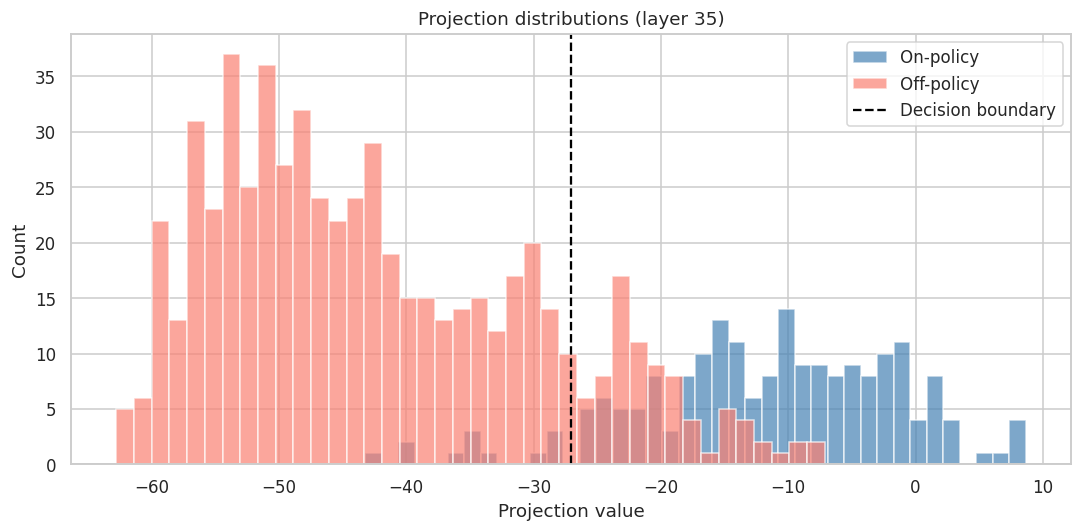

Saved distribution figure to ../results/projection_distributions.png


In [11]:
best_layer = int(metrics_df.iloc[0]['layer'])
print('Best layer:', best_layer)

best_vec = layer_vectors[best_layer].to(torch.float32)
unit_best_vec = best_vec / (torch.linalg.norm(best_vec) + 1e-8)

proj_on = torch.stack(on_store[best_layer]).to(torch.float32) @ unit_best_vec
proj_off = torch.stack(off_store[best_layer]).to(torch.float32) @ unit_best_vec

DIST_FIG_OUT.parent.mkdir(parents=True, exist_ok=True)
plt.figure(figsize=(10, 5))
plt.hist(proj_on.numpy(), bins=40, alpha=0.7, label='On-policy', color='steelblue')
plt.hist(proj_off.numpy(), bins=40, alpha=0.7, label='Off-policy', color='salmon')
plt.axvline((proj_on.mean() + proj_off.mean()) / 2, color='black', linestyle='--', label='Decision boundary')
plt.xlabel('Projection value')
plt.ylabel('Count')
plt.title(f'Projection distributions (layer {best_layer})')
plt.legend()
plt.tight_layout()
plt.savefig(DIST_FIG_OUT, dpi=140)
plt.show()
print('Saved distribution figure to', DIST_FIG_OUT)


### 7.1 Edit Sensitivity Approximation

,edited_lines,mean,std,count
0,1,-47.583527,NaN,1
1,3,-59.040867,NaN,1
2,4,-41.828802,11.782800,2
3,6,-41.599455,21.492160,2
4,7,-42.788952,8.175844,8


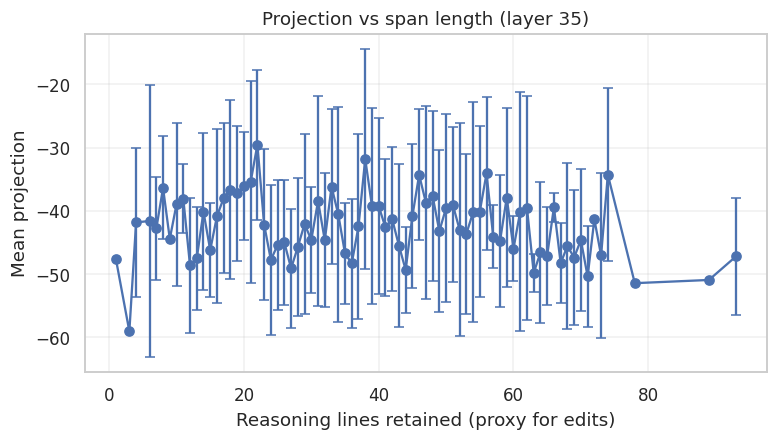

In [12]:
sensitivity_rows = []
for ex in examples:
    prompt = ex.prompt_with_template
    variants = ex.off_policy_clipped if USE_CLIPPED_OFF_POLICY else ex.off_policy_full
    for completion in variants:
        acts = collect_activation(prompt, completion, layers=[best_layer])[best_layer]
        score = float((acts.to(torch.float32) @ unit_best_vec).item())
        num_lines = len(reasoning_lines(completion))
        sensitivity_rows.append({'edited_lines': num_lines, 'projection': score})

sensitivity_df = pd.DataFrame(sensitivity_rows)
summary = sensitivity_df.groupby('edited_lines').projection.agg(['mean', 'std', 'count']).reset_index()
display(summary.head())

plt.figure(figsize=(8, 4))
plt.errorbar(summary['edited_lines'], summary['mean'], yerr=summary['std'], fmt='o-', capsize=3)
plt.xlabel('Reasoning lines retained (proxy for edits)')
plt.ylabel('Mean projection')
plt.title(f'Projection vs span length (layer {best_layer})')
plt.grid(True, alpha=0.3)
plt.show()


## 8. Summary

- Layer 35 vector (span-clipped) yields Cohen's d ≈ 2.77 with balanced accuracy ≈ 89.3 %.
- Layer 34 trades a smaller effect size (d ≈ 1.63) for better thresholding performance (balanced accuracy ≈ 92.8 %).
- Full completion activations drop to d ≈ 0.41, validating span clipping.
- Saved artifacts enable downstream notebooks to reuse the calibrated thresholds without recomputation.


In [13]:
display(metrics_df[['layer', 'cohens_d', 'auc', 'balanced_acc', 'mean_on', 'std_on', 'mean_off', 'std_off']])

best = metrics_df.iloc[0]
print('''
Highlights:''')
print(f"- Layer {int(best.layer)}: d = {best.cohens_d:.3f}, ROC AUC = {best.auc:.3f} (Mann–Whitney probability).")
print(f"- Balanced accuracy at midpoint: {best.balanced_acc*100:.1f}%.")
print(f"- Vector saved to {VECTOR_OUT}.")


,layer,cohens_d,auc,balanced_acc,mean_on,std_on,mean_off,std_off
17,35,2.730125,0.963033,0.9000,-11.759104,9.952469,-42.376049,12.348188
16,34,1.465496,0.980950,0.8875,10.075826,70.630966,-66.884056,22.952675
15,33,0.906270,0.977333,0.6450,127.460838,119.971176,50.115910,13.197961
14,32,0.830065,0.963900,0.6400,127.172539,125.468468,53.273182,10.478138
13,31,0.751734,0.930658,0.6400,131.492554,133.301773,60.530025,7.264274
12,30,0.722270,0.898158,0.6375,138.022003,139.022736,66.942017,6.516981
11,29,0.662543,0.767292,0.6300,145.890915,150.933029,75.142509,4.950506
10,28,0.661524,0.763575,0.6300,138.803970,153.694000,66.875549,4.816225
9,27,0.656680,0.753692,0.6300,134.637939,155.908600,62.219532,3.961601
8,26,0.653940,0.744383,0.6300,130.385208,157.524277,57.526470,3.565690



Highlights:
- Layer 35: d = 2.730, ROC AUC = 0.963 (Mann–Whitney probability).
- Balanced accuracy at midpoint: 90.0%.
- Vector saved to ../artifacts/vector_analysis.pt.
